<a href="https://colab.research.google.com/github/tejinderpa/LangGraphs/blob/graphs/KeyboardInterrupt_Resuming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install langgraph

In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [3]:
#1. Define the state
class CrashState(TypedDict):
  input : str
  step1 : str
  step2 : str
  step3 : str

In [4]:
def step_1(state: CrashState) -> CrashState:
  print('Step1 executed')
  return {"step1" : "done", "input" : state["input"]}

def step_2(state: CrashState) -> CrashState:
  print('Step2 hanging... now manually interrupt from the notebook toobar')
  time.sleep(30)
  return {"step2" : "done"}

def step_3(state: CrashState) -> CrashState:
  print('Step3 executed')
  return {"step3" : "done"}

In [5]:
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

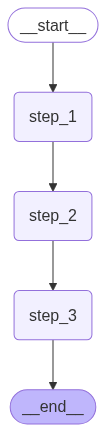

In [6]:
graph

In [7]:
try:
  print("Running graph: Please manually interrupt during Step 2...")
  graph.invoke({"input": "start"}, config={"configurable" : {"thread_id":'thread-1'}})

except KeyboardInterrupt:
  print("Keyboard Interrupt (Crash Simulated)")

Running graph: Please manually interrupt during Step 2...
Step1 executed
Step2 hanging... now manually interrupt from the notebook toobar
Keyboard Interrupt (Crash Simulated)


In [9]:
graph.get_state({"configurable":{"thread_id":'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0810a7-ae3f-61e3-8001-0b707ebc784a'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-08-24T16:50:45.990022+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0810a7-ae3c-60ea-8000-f401772abdd3'}}, tasks=(PregelTask(id='3e079296-0098-84c6-f468-576ae3b6c9cd', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [10]:
list(graph.get_state({"configurable":{"thread_id":'thread-1'}}))

[{'input': 'start', 'step1': 'done'},
 ('step_2',),
 {'configurable': {'thread_id': 'thread-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f0810a7-ae3f-61e3-8001-0b707ebc784a'}},
 {'source': 'loop', 'step': 1, 'parents': {}},
 '2025-08-24T16:50:45.990022+00:00',
 {'configurable': {'thread_id': 'thread-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f0810a7-ae3c-60ea-8000-f401772abdd3'}},
 (PregelTask(id='3e079296-0098-84c6-f468-576ae3b6c9cd', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),),
 ()]

In [12]:
final_state = graph.invoke(None, config={"configurable" : {"thread_id":'thread-1'}})
print("\n Final State :", final_state)

Step2 hanging... now manually interrupt from the notebook toobar
Step3 executed

 Final State : {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [13]:
graph.get_state({"configurable":{"thread_id":'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0810b1-92f2-6926-8003-3707d95f6da1'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-08-24T16:55:11.562966+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0810b1-92f0-64e6-8002-df7c01d7f8f8'}}, tasks=(), interrupts=())

In [14]:
list(graph.get_state({"configurable":{"thread_id":'thread-1'}}))

[{'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'},
 (),
 {'configurable': {'thread_id': 'thread-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f0810b1-92f2-6926-8003-3707d95f6da1'}},
 {'source': 'loop', 'step': 3, 'parents': {}},
 '2025-08-24T16:55:11.562966+00:00',
 {'configurable': {'thread_id': 'thread-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f0810b1-92f0-64e6-8002-df7c01d7f8f8'}},
 (),
 ()]